In [1]:
import os

import galsim
import batsim
import anacal
import numpy as np
import matplotlib.pyplot as plt

from multiprocessing import cpu_count
from parallelbar import progress_starmap
from tqdm import tqdm
from time import time

from importlib import reload
reload(batsim)

<module 'batsim' from '/home/b7009348/FPFS-project/BATSim/src/batsim/__init__.py'>

In [3]:
IATransform = batsim.IaTransform(
    scale=0.2,
    hlr=0.5,
    A=0.00136207,
    beta=0.82404653, # best first Georgiou19+
    phi = np.radians(60),
    clip_radius=5 # clip the transform at 5*hlr to prevent edge effects
)

g1, g2 = IATransform.get_g1g2(x=1, y=1)
print(g1, g2)

-0.0008021113079329497 0.0013892975386653947


-0.0008021113079329497 0.0013892975386653947

In [5]:
gal = galsim.Sersic(n=5, half_light_radius=0.5, flux=1e5)
seeing = 0.8
psf = galsim.Moffat(beta=2.5, fwhm=seeing, trunc=seeing*4)

LensTransform = batsim.LensTransform(gamma1=0.02, gamma2=0.0, kappa=0)

IATransform = batsim.IaTransform(
    scale=0.2,
    hlr=0.5,
    A=0.00136207,
    beta=0.82404653, # best first Georgiou19+
    phi = np.radians(0),
    clip_radius=5 # clip the transform at 5*hlr to prevent edge effects
)

for _ in range(4):
    start = time()
    gal_img = batsim.simulate_galaxy(
        ngrid=64,
        pix_scale=0.2,
        gal_obj=gal,
        transform_obj=IATransform,
        psf_obj=psf,
        truncate_ratio=0.5,
        draw_method="auto",
        profile=True
    )
    end = time()
    print(f"BATSim TOTAL: {end - start:.2e} seconds")

# Compare to vanilla GalSim
start = time()
gal = gal.shear(g1=0.02)
gal = galsim.Convolve([gal, psf])
gal_img_gs = gal.drawImage(scale=0.2, method="auto")
end = time()
print(f"GalSim TOTAL: {end - start:.2e} seconds")

[simulate_galaxy] effective_scale_padding=2.1065e-02s
[simulate_galaxy] grid_sizing=2.2721e-05s
[simulate_galaxy] coords_transform=1.7690e+00s
[simulate_galaxy] sample_flux=1.5280e-01s
[simulate_galaxy] prepare_psf=5.1639e-05s
[simulate_galaxy] convolution_downsample=2.9429e-01s
[simulate_galaxy] stats nn=4096 downsample_ratio=64 scale=3.1250e-03 pad_arcsec=4.8921e-01 draw_method=auto
[simulate_galaxy] total=2.2376e+00s
BATSim TOTAL: 2.24e+00 seconds
[simulate_galaxy] effective_scale_padding=4.0590e-05s
[simulate_galaxy] grid_sizing=2.7684e-05s
[simulate_galaxy] coords_transform=1.7523e+00s
[simulate_galaxy] sample_flux=1.4853e-01s
[simulate_galaxy] prepare_psf=5.2095e-05s
[simulate_galaxy] convolution_downsample=2.6403e-01s
[simulate_galaxy] stats nn=4096 downsample_ratio=64 scale=3.1250e-03 pad_arcsec=4.8921e-01 draw_method=auto
[simulate_galaxy] total=2.1655e+00s
BATSim TOTAL: 2.17e+00 seconds
[simulate_galaxy] effective_scale_padding=4.5077e-05s
[simulate_galaxy] grid_sizing=3.2015

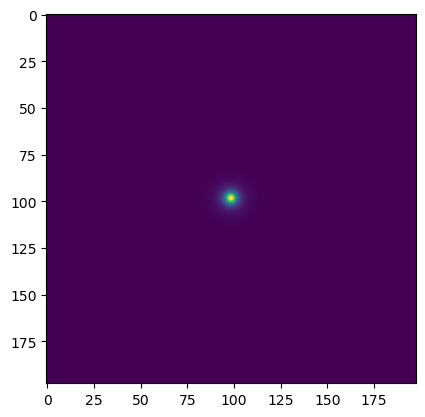

In [6]:
plt.imshow(gal_img_gs.array)

In [8]:
gal.nyquist_scale
gal.getGoodImageSize(gal.nyquist_scale)

164

In [5]:
nn = 64
scale = 0.2

ind = 14

cosmos = galsim.COSMOSCatalog()
gal = cosmos.makeGalaxy(index=ind, gal_type="parametric")
gal = gal.withFlux(1)
print(f"Nyquist scale: {gal.nyquist_scale}")
print(f"Heuristic: {scale / 4.0}")
rec = cosmos.getParametricRecord(ind)

if bool(rec["use_bulgefit"]): 
    print("Bulge+Disk") 
elif bool(rec["viable_sersic"]): 
    print("Sersic")
else: 
    print("Unknown")

psf = galsim.Moffat(beta=2.5, fwhm=0.8, trunc=3.2, flux=1)
gal_conv = galsim.Convolve([gal, psf])

galsim_image = (
    gal_conv.shift(scale * 0.5, scale * 0.5)
    .drawImage(nx=nn, ny=nn, scale=scale, method="no_pixel")
    .array
)

batsim_image = batsim.simulate_galaxy(
    ngrid=nn,
    pix_scale=scale,
    gal_obj=gal,
    transform_obj=None,
    psf_obj=psf,
    truncate_ratio=1.0,
    draw_method="no_pixel",
    profile=True
)

np.testing.assert_array_almost_equal(batsim_image, galsim_image, decimal=4)

Nyquist scale: 0.0746072712290495
Heuristic: 0.05
Sersic
[simulate_galaxy] effective_scale_padding=1.5399e-02s
[simulate_galaxy] grid_sizing=1.3702e-05s
[simulate_galaxy] coords_transform=7.4620e-04s
[simulate_galaxy] sample_flux=6.0124e-04s
[simulate_galaxy] convolution_downsample=2.1735e-03s
[simulate_galaxy] stats nn=256 downsample_ratio=4 scale=5.0000e-02 pad_arcsec=4.8921e-01 draw_method=no_pixel
[simulate_galaxy] total=1.9032e-02s


TypeError: sum() missing 1 required positional argument: 'a'

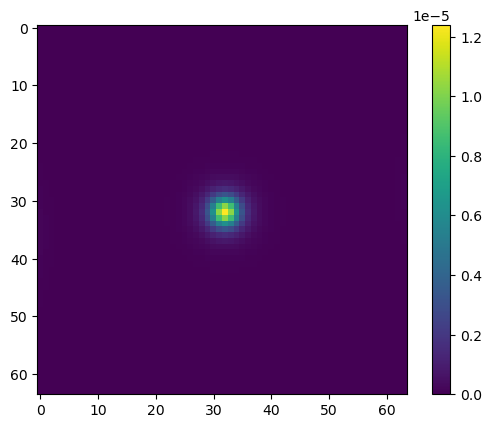

In [6]:
plt.imshow(batsim_image - galsim_image)
plt.colorbar()
np.sum()

In [ ]:
scale = 0.2

inds = np.arange(len(cosmos))
cosmos_full = cosmos.makeGalaxy(index=inds, gal_type="parametric")

# render_stats = {}
# for gal in tqdm(cosmos_full):
#     nyq = gal.nyquist_scale
#     heuristic = scale / 2.0
#     render_scale = min(nyq, heuristic)
#     downsample_ratio = min(int(2 ** np.ceil(np.log2(scale / render_scale))), 128)
#     render_stats[gal.index] = {
#         "nyquist_scale": nyq, 
#         "heuristic": heuristic,
#         "render_scale": render_scale, 
#         "downsample_ratio": downsample_ratio
#     }
    


100%|██████████| 81499/81499 [02:54<00:00, 468.28it/s] 


In [ ]:
# Asses what the largest downsample ratio was and how frequently it was used
max_downsample = max([s["downsample_ratio"] for s in render_stats.values()])
print(f"Max downsample ratio: {max_downsample}")
downsample_counts = {r: sum(1 for s in render_stats.values() if s["downsample_ratio"] == r) for r in set(s["downsample_ratio"] for s in render_stats.values())}
print("Downsample ratio counts:")
for r, count in sorted(downsample_counts.items()):
    print(f"  Ratio {r}: {count} galaxies")

# Determine minimum nyquist scale and how often nyquist scale was below the heuristic
min_nyquist = min(s["nyquist_scale"] for s in render_stats.values())
print(f"Minimum Nyquist scale: {min_nyquist}")
below_heuristic_count = sum(1 for s in render_stats.values() if s["nyquist_scale"] < s["heuristic"])
print(f"Galaxies with Nyquist scale below heuristic: {below_heuristic_count} ({below_heuristic_count / len(render_stats) * 100:.2f}%)")

Max downsample ratio: 128
Downsample ratio counts:
  Ratio 2: 6324 galaxies
  Ratio 4: 12083 galaxies
  Ratio 8: 14508 galaxies
  Ratio 16: 9796 galaxies
  Ratio 32: 5533 galaxies
  Ratio 64: 4620 galaxies
  Ratio 128: 28635 galaxies
Minimum Nyquist scale: 2.282976907621309e-06
Galaxies with Nyquist scale below heuristic: 75175 (92.24%)
